## **VOYAGE ANALYTICS - GENDER CLASSIFICATION MODEL**
### Goal : Predict user gender (male/female/none)

### **Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score)

print("-> All libraries imported successfully")

-> All libraries imported successfully


### **Load Data**

In [2]:
DATA_PATH = '../data/'

users   = pd.read_csv(DATA_PATH + 'users.csv')
flights = pd.read_csv(DATA_PATH + 'flights.csv')
hotels  = pd.read_csv(DATA_PATH + 'hotels.csv')

print("=" * 50)
print("DATASETS LOADED")
print("=" * 50)
print(f"Users   : {users.shape}")
print(f"Flights : {flights.shape}")
print(f"Hotels  : {hotels.shape}")

print(f"\nUSERS - First 5 Rows:")
print(users.head())

print(f"\nGender Distribution:")
print(users['gender'].value_counts())

DATASETS LOADED
Users   : (1340, 5)
Flights : (271888, 10)
Hotels  : (40552, 8)

USERS - First 5 Rows:
   code company             name  gender  age
0     0    4You        Roy Braun    male   21
1     1    4You   Joseph Holsten    male   37
2     2    4You    Wilma Mcinnis  female   48
3     3    4You     Paula Daniel  female   23
4     4    4You  Patricia Carson  female   44

Gender Distribution:
gender
male      452
female    448
none      440
Name: count, dtype: int64


### **Feature Engineering (Build User-Level Features)**

In [3]:
# HYPOTHESIS TESTING INSIGHTS APPLIED:
# - Flight price DIFFERS across genders (significant)
# - Flight class preference DEPENDS on gender (significant)
# - Age and hotel spending NOT significant
# We include all features and let the model decide importance

# FLIGHT FEATURES per user
flights['date'] = pd.to_datetime(flights['date'])
flights['month'] = flights['date'].dt.month

# Aggregate flight behavior per user
flight_features = flights.groupby('userCode').agg(
    total_flights = ('travelCode', 'count'),
    avg_flight_price = ('price', 'mean'),
    max_flight_price = ('price', 'max'),
    min_flight_price = ('price', 'min'),
    std_flight_price = ('price', 'std'),
    avg_distance = ('distance', 'mean'),
    firstClass_count = ('flightType', lambda x: (x == 'firstClass').sum()),
    premium_count = ('flightType', lambda x: (x == 'premium').sum()),
    economic_count = ('flightType', lambda x: (x == 'economic').sum()),
    rainbow_count = ('agency', lambda x: (x == 'Rainbow').sum()),
    cloudfy_count = ('agency', lambda x: (x == 'CloudFy').sum()),
    flyingdrops_count = ('agency', lambda x: (x == 'FlyingDrops').sum()),
    peak_month_bookings = ('month', lambda x: (x == 10).sum()),
).reset_index()

# Ratios (% of each class)
flight_features['firstClass_ratio'] = (
    flight_features['firstClass_count'] / flight_features['total_flights']
)
flight_features['premium_ratio'] = (
    flight_features['premium_count'] / flight_features['total_flights']
)
flight_features['economic_ratio'] = (
    flight_features['economic_count'] / flight_features['total_flights']
)

print("Flight features shape:", flight_features.shape)
print(flight_features.head())

Flight features shape: (1335, 17)
   userCode  total_flights  avg_flight_price  max_flight_price  \
0         0            178        989.066124           1724.49   
1         1             12        818.898333           1269.73   
2         2            262        906.921832           1723.71   
3         3            398        936.913894           1724.49   
4         4            398        957.393417           1724.49   

   min_flight_price  std_flight_price  avg_distance  firstClass_count  \
0            301.51        370.237372    527.233596                88   
1            559.13        196.008184    508.648333                 2   
2            301.51        357.965935    513.671374                98   
3            301.51        359.765705    506.074372               172   
4            301.61        372.719529    517.955477               180   

   premium_count  economic_count  rainbow_count  cloudfy_count  \
0             46              44             68             78  

### **Hotel Features**

In [4]:
# HOTEL FEATURES per user
hotel_features = hotels.groupby('userCode').agg(
    total_hotel_bookings = ('travelCode', 'count'),
    avg_hotel_price = ('price', 'mean'),
    avg_stay_days = ('days', 'mean'),
    avg_total_spend = ('total', 'mean'),
    max_total_spend = ('total', 'max'),
).reset_index()

print("Hotel features shape:", hotel_features.shape)
print(hotel_features.head())

Hotel features shape: (1310, 6)
   userCode  total_hotel_bookings  avg_hotel_price  avg_stay_days  \
0         0                    27       225.741481       2.629630   
1         1                     2       193.360000       1.000000   
2         2                    36       210.050000       2.694444   
3         3                    60       217.058500       2.300000   
4         4                    56       214.947679       2.571429   

   avg_total_spend  max_total_spend  
0       593.145185          1252.08  
1       193.360000           247.62  
2       558.003333          1252.08  
3       499.568500          1252.08  
4       565.316071          1252.08  


### **Merge Everything**

In [5]:
# MERGE ALL FEATURES WITH USERS
df = users.copy()

# Merge flights
df = df.merge(flight_features, left_on='code', right_on='userCode', 
              how='left').drop(columns=['userCode'])

# Merge hotels
df = df.merge(hotel_features, left_on='code', right_on='userCode', 
              how='left').drop(columns=['userCode'])

print("=" * 50)
print("MERGED DATASET")
print("=" * 50)
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

MERGED DATASET
Shape : (1340, 26)
Columns : ['code', 'company', 'name', 'gender', 'age', 'total_flights', 'avg_flight_price', 'max_flight_price', 'min_flight_price', 'std_flight_price', 'avg_distance', 'firstClass_count', 'premium_count', 'economic_count', 'rainbow_count', 'cloudfy_count', 'flyingdrops_count', 'peak_month_bookings', 'firstClass_ratio', 'premium_ratio', 'economic_ratio', 'total_hotel_bookings', 'avg_hotel_price', 'avg_stay_days', 'avg_total_spend', 'max_total_spend']

Missing values:
code                     0
company                  0
name                     0
gender                   0
age                      0
total_flights            5
avg_flight_price         5
max_flight_price         5
min_flight_price         5
std_flight_price         5
avg_distance             5
firstClass_count         5
premium_count            5
economic_count           5
rainbow_count            5
cloudfy_count            5
flyingdrops_count        5
peak_month_bookings      5
firstClas

### **Handle Missing Values**

In [6]:
# HANDLE MISSING VALUES
print("BEFORE filling NaN:")
print(f"  Total missing: {df.isnull().sum().sum()}")

# Users with no flight data (5 users) → fill with 0
flight_cols = [
    'total_flights', 'avg_flight_price', 'max_flight_price',
    'min_flight_price', 'std_flight_price', 'avg_distance',
    'firstClass_count', 'premium_count', 'economic_count',
    'rainbow_count', 'cloudfy_count', 'flyingdrops_count',
    'peak_month_bookings', 'firstClass_ratio', 'premium_ratio',
    'economic_ratio'
]

# Users with no hotel data (30 users) → fill with 0
hotel_cols = [
    'total_hotel_bookings', 'avg_hotel_price',
    'avg_stay_days', 'avg_total_spend', 'max_total_spend'
]

df[flight_cols] = df[flight_cols].fillna(0)
df[hotel_cols] = df[hotel_cols].fillna(0)

print("AFTER filling NaN:")
print(f"  Total missing : {df.isnull().sum().sum()}")
print(f"  Shape : {df.shape}")

BEFORE filling NaN:
  Total missing: 230
AFTER filling NaN:
  Total missing : 0
  Shape : (1340, 26)


### **PREPARE FEATURES (X) AND TARGET (y)**

In [7]:
# Drop non-feature columns
COLS_TO_DROP = ['code', 'name', 'gender', 'company']

X_raw = df.drop(columns=COLS_TO_DROP)
y_raw = df['gender']

print("FEATURE COLUMNS:")
for i, col in enumerate(X_raw.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFeature Matrix X : {X_raw.shape}")
print(f"Target Vector y : {y_raw.shape}")
print(f"\nTarget distribution :\n{y_raw.value_counts()}")

FEATURE COLUMNS:
   1. age
   2. total_flights
   3. avg_flight_price
   4. max_flight_price
   5. min_flight_price
   6. std_flight_price
   7. avg_distance
   8. firstClass_count
   9. premium_count
  10. economic_count
  11. rainbow_count
  12. cloudfy_count
  13. flyingdrops_count
  14. peak_month_bookings
  15. firstClass_ratio
  16. premium_ratio
  17. economic_ratio
  18. total_hotel_bookings
  19. avg_hotel_price
  20. avg_stay_days
  21. avg_total_spend
  22. max_total_spend

Feature Matrix X : (1340, 22)
Target Vector y : (1340,)

Target distribution :
gender
male      452
female    448
none      440
Name: count, dtype: int64


### **ENCODE COMPANY (CATEGORICAL)**

In [8]:
# Company is a meaningful feature — one-hot encode it
company_dummies = pd.get_dummies(df['company'],
    prefix = 'company',
    drop_first = False        # keep all 5 for interpretability
)

X = pd.concat([X_raw, company_dummies], axis=1)

print(f"Shape after company encoding: {X.shape}")
print(f"New company columns: {company_dummies.columns.tolist()}")

Shape after company encoding: (1340, 27)
New company columns: ['company_4You', 'company_Acme Factory', 'company_Monsters CYA', 'company_Umbrella LTDA', 'company_Wonka Company']


### **ENCODE TARGET (GENDER)**

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

print(f"Label Encoding:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    count = (y_raw == cls).sum()
    print(f"  {cls:8s} -> {enc}  (n={count})")

# Check class balance
print(f"\nClass balance check:")
unique, counts = np.unique(y_encoded, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    pct = cnt / len(y_encoded) * 100
    print(f"  {cls:8s}: {cnt} ({pct:.1f}%)")
print("-> Classes are well balanced (~33% each)")

Label Encoding:
  female   -> 0  (n=448)
  male     -> 1  (n=452)
  none     -> 2  (n=440)

Class balance check:
  female  : 448 (33.4%)
  male    : 452 (33.7%)
  none    : 440 (32.8%)
-> Classes are well balanced (~33% each)


### **TRAIN-TEST SPLIT**

In [10]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size = 0.2,
    random_state = 42,
    stratify = y_encoded    # preserve class balance
)

# Scale features (for Logistic Regression)
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

print(f"Total Samples : {len(X):,}")
print(f"Training Set : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test Set : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

print(f"\nTrain class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls:8s}: {cnt}")

print(f"\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls:8s}: {cnt}")

Total Samples : 1,340
Training Set : 1,072 (80%)
Test Set : 268  (20%)

Train class distribution:
  female  : 358
  male    : 362
  none    : 352

Test class distribution:
  female  : 90
  male    : 90
  none    : 88


### **TRAIN AND COMPARE MODELS**

In [11]:
def evaluate_classifier(name, model, X_tr, X_te, y_tr, y_te):
    """Train model and return full metrics."""
    model.fit(X_tr, y_tr)

    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    metrics = {
        'Model' : name,
        'Train Acc' : round(accuracy_score(y_tr, y_pred_train), 4),
        'Test Acc' : round(accuracy_score(y_te, y_pred_test), 4),
        'F1 Macro' : round(f1_score(y_te, y_pred_test, average='macro'), 4),
        'F1 Weighted' : round(f1_score(y_te, y_pred_test, average='weighted'), 4),
    }
    return metrics, model, y_pred_test


# Models to compare
models_to_try = {
    'Logistic Regression' : LogisticRegression(max_iter = 1000, random_state = 42, solver = 'lbfgs'
                            ),
    'Random Forest' : RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1
                            ),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, 
                                max_depth = 4, random_state = 42),
}

results        = []
trained_models = {}

print("TRAINING MODELS...")
print("=" * 65)

for name, model in models_to_try.items():
    print(f"  Training {name}...", end='', flush=True)

    # Logistic Regression needs scaled data
    if name == 'Logistic Regression':
        metrics, trained, y_pred = evaluate_classifier(
            name, model, 
            X_train_scaled, X_test_scaled,
            y_train, y_test
        )
    else:
        metrics, trained, y_pred = evaluate_classifier(
            name, model,
            X_train, X_test,
            y_train, y_test
        )

    results.append(metrics)
    trained_models[name] = (trained, y_pred)
    print(f" -> Test Acc: {metrics['Test Acc']} | F1 Macro: {metrics['F1 Macro']}")


# Results table
results_df = pd.DataFrame(results).sort_values('Test Acc', ascending=False)

print("\n")
print("=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

best_name = results_df.iloc[0]['Model']
best_model_obj = trained_models[best_name][0]
best_y_pred = trained_models[best_name][1]
print(f"\n-> Best Model: {best_name}")

TRAINING MODELS...
  Training Logistic Regression...

 -> Test Acc: 0.3657 | F1 Macro: 0.3644
  Training Random Forest...

 -> Test Acc: 0.3097 | F1 Macro: 0.3095
  Training Gradient Boosting...

 -> Test Acc: 0.3246 | F1 Macro: 0.3221


MODEL COMPARISON RESULTS
              Model  Train Acc  Test Acc  F1 Macro  F1 Weighted
Logistic Regression     0.4095    0.3657    0.3644       0.3645
  Gradient Boosting     0.9739    0.3246    0.3221       0.3219
      Random Forest     1.0000    0.3097    0.3095       0.3097

-> Best Model: Logistic Regression


In [12]:
# WHY LOGISTIC REGRESSION WON
# Small dataset (1340 users) + weak signal = 
# simpler models generalize better
# Random Forest/GBM overfit on 1340 samples

print("ROOT CAUSE ANALYSIS")
print("=" * 60)
print(f"Dataset size : {len(X)} users (VERY SMALL)")
print(f"Number of classes : {len(le.classes_)}")
print(f"Random baseline : {1/len(le.classes_)*100:.1f}%")
print(f"Best achieved : {36.57:.2f}%")
print(f"Improvement : {36.57 - 33.33:.2f}% above random")
print()
print("DIAGNOSIS:")
print("  Random Forest -> Train=1.0  Test=0.31 -> OVERFIT")
print("  Gradient Boost -> Train=0.97 Test=0.32 -> OVERFIT")
print("  Logistic Reg -> Train=0.41 Test=0.37 -> BEST FIT")
print()
print("REASON: Gender has almost no predictable signal")
print("  from travel behavior in this dataset.")
print("  Hypothesis tests confirmed features differ")
print("  statistically but NOT practically.")

ROOT CAUSE ANALYSIS
Dataset size : 1340 users (VERY SMALL)
Number of classes : 3
Random baseline : 33.3%
Best achieved : 36.57%
Improvement : 3.24% above random

DIAGNOSIS:
  Random Forest -> Train=1.0  Test=0.31 -> OVERFIT
  Gradient Boost -> Train=0.97 Test=0.32 -> OVERFIT
  Logistic Reg -> Train=0.41 Test=0.37 -> BEST FIT

REASON: Gender has almost no predictable signal
  from travel behavior in this dataset.
  Hypothesis tests confirmed features differ
  statistically but NOT practically.


### **IMPROVEMENT STRATEGY 1: CLASS WEIGHTS**

In [13]:
# Even though balanced, explicit weights help LR find boundaries

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

print("\nSTRATEGY 1: Trying more models suited for small datasets")
print("=" * 60)

extended_models = {
    'Logistic Reg (balanced)' : LogisticRegression(max_iter = 1000, random_state = 42,
                                    class_weight = 'balanced', C = 1.0
                                ),
    'Logistic Reg (C=0.1)' : LogisticRegression(max_iter = 1000, random_state = 42, C = 0.1   # more regularization
                                ),
    'Logistic Reg (C=10)' : LogisticRegression(max_iter = 1000, random_state = 42, C = 10.0
                                ),
    'Naive Bayes' : GaussianNB(),
    'KNN (k=5)' : KNeighborsClassifier(n_neighbors=5),
    'KNN (k=11)' : KNeighborsClassifier(n_neighbors=11),
    'SVM (RBF)' : SVC(kernel = 'rbf', random_state = 42, probability  = True
                                ),
    'SVM (Linear)' : SVC(kernel = 'linear', random_state = 42, probability = True
                                ),
}

ext_results = []

for name, model in extended_models.items():
    # All these models work best with scaled data
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')

    ext_results.append({
        'Model' : name,
        'Train Acc' : round(train_acc, 4),
        'Test Acc' : round(test_acc, 4),
        'F1 Macro' : round(f1_mac, 4),
        'Overfit Gap' : round(train_acc - test_acc, 4)
    })
    print(f"  {name:30s} -> Test: {test_acc:.4f} | F1: {f1_mac:.4f}")

ext_df = pd.DataFrame(ext_results).sort_values('Test Acc', ascending=False)
print(f"\n{'='*70}")
print("EXTENDED MODEL COMPARISON")
print(f"{'='*70}")
print(ext_df.to_string(index=False))


STRATEGY 1: Trying more models suited for small datasets
  Logistic Reg (balanced)        -> Test: 0.3769 | F1: 0.3769
  Logistic Reg (C=0.1)           -> Test: 0.3657 | F1: 0.3664
  Logistic Reg (C=10)            -> Test: 0.3881 | F1: 0.3857
  Naive Bayes                    -> Test: 0.3246 | F1: 0.2826
  KNN (k=5)                      -> Test: 0.3470 | F1: 0.3414


  KNN (k=11)                     -> Test: 0.3433 | F1: 0.3430


  SVM (RBF)                      -> Test: 0.3769 | F1: 0.3765


  SVM (Linear)                   -> Test: 0.3694 | F1: 0.3696

EXTENDED MODEL COMPARISON
                  Model  Train Acc  Test Acc  F1 Macro  Overfit Gap
    Logistic Reg (C=10)     0.4049    0.3881    0.3857       0.0168
Logistic Reg (balanced)     0.4076    0.3769    0.3769       0.0308
              SVM (RBF)     0.4991    0.3769    0.3765       0.1222
           SVM (Linear)     0.3974    0.3694    0.3696       0.0280
   Logistic Reg (C=0.1)     0.4095    0.3657    0.3664       0.0438
              KNN (k=5)     0.5672    0.3470    0.3414       0.2201
             KNN (k=11)     0.4972    0.3433    0.3430       0.1539
            Naive Bayes     0.3685    0.3246    0.2826       0.0438


### **IMPROVEMENT STRATEGY 2: FEATURE SELECTION**

In [14]:
# Remove noise features, keep only statistically relevant ones

from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.pipeline import Pipeline

print("\nSTRATEGY 2: Feature Selection (keep top-k features)")
print("=" * 60)

# Based on hypothesis testing — these matter most:
# avg_flight_price (Test 2 significant)
# firstClass_ratio, premium_ratio, economic_ratio (Test 3 significant)
# Company features (may help separate groups)

# Try SelectKBest with different k values
for k in [5, 8, 10, 15, 'all']:
    
    if k == 'all':
        X_tr_sel = X_train_scaled
        X_te_sel = X_test_scaled
        label = 'all features'
    else:
        selector = SelectKBest(f_classif, k=k)
        X_tr_sel = selector.fit_transform(X_train_scaled, y_train)
        X_te_sel = selector.transform(X_test_scaled)
        label = f'top {k} features'

    lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    lr.fit(X_tr_sel, y_train)
    acc = accuracy_score(y_test, lr.predict(X_te_sel))
    f1  = f1_score(y_test, lr.predict(X_te_sel), average='macro')
    print(f"  LR with {label:18s} -> Acc: {acc:.4f} | F1: {f1:.4f}")


STRATEGY 2: Feature Selection (keep top-k features)
  LR with top 5 features     -> Acc: 0.3358 | F1: 0.3371
  LR with top 8 features     -> Acc: 0.3134 | F1: 0.3079
  LR with top 10 features    -> Acc: 0.3470 | F1: 0.3486
  LR with top 15 features    -> Acc: 0.3470 | F1: 0.3462
  LR with all features       -> Acc: 0.3657 | F1: 0.3644


### **IMPROVEMENT STRATEGY 3: TUNED LOGISTIC REGRESSION**

In [15]:
# LR is already best - let's properly tune it

from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("\nSTRATEGY 3: Tune the best model (Logistic Regression)")
print("=" * 60)

lr_param_grid = {
    'C' : [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'penalty' : ['l2'],
    'class_weight' : [None, 'balanced'],
    'solver' : ['lbfgs', 'saga']
}

lr_grid = GridSearchCV(
    estimator = LogisticRegression(max_iter=2000, random_state=42),
    param_grid = lr_param_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = 'f1_macro', n_jobs = -1, verbose = 0
)

lr_grid.fit(X_train_scaled, y_train)

print(f"Best Parameters : {lr_grid.best_params_}")
print(f"Best CV F1 Macro : {lr_grid.best_score_:.4f}")

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

print(f"\nTUNED LOGISTIC REGRESSION - TEST SET:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  F1 Macro : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"  F1 Weighted : {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")


STRATEGY 3: Tune the best model (Logistic Regression)


Best Parameters : {'C': 10.0, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Best CV F1 Macro : 0.3499

TUNED LOGISTIC REGRESSION - TEST SET:
  Accuracy : 0.4030
  F1 Macro : 0.4036
  F1 Weighted : 0.4035


### **FINAL MODEL CONFIRMATION**

In [16]:
print("FINAL MODEL SELECTED")
print("=" * 60)
print(f"  Algorithm : Logistic Regression (Tuned)")
print(f"  C : 10.0")
print(f"  class_weight : balanced")
print(f"  penalty : l2")
print(f"  solver : saga")
print(f"  Test Accuracy : 0.4030")
print(f"  F1 Macro : 0.4036")
print(f"  vs Baseline : +6.97% over random (33.33%)")
print("=" * 60)

FINAL MODEL SELECTED
  Algorithm : Logistic Regression (Tuned)
  C : 10.0
  class_weight : balanced
  penalty : l2
  solver : saga
  Test Accuracy : 0.4030
  F1 Macro : 0.4036
  vs Baseline : +6.97% over random (33.33%)


### **FINAL CLASSIFICATION REPORT**

In [17]:
print("\nDETAILED CLASSIFICATION REPORT - FINAL MODEL")
print("=" * 60)
print(classification_report(
    y_test, 
    y_pred_lr,          # from Strategy 3
    target_names = le.classes_
))


DETAILED CLASSIFICATION REPORT - FINAL MODEL
              precision    recall  f1-score   support

      female       0.39      0.41      0.40        90
        male       0.38      0.40      0.39        90
        none       0.45      0.40      0.42        88

    accuracy                           0.40       268
   macro avg       0.41      0.40      0.40       268
weighted avg       0.41      0.40      0.40       268



### **FINAL CONFUSION MATRIX**

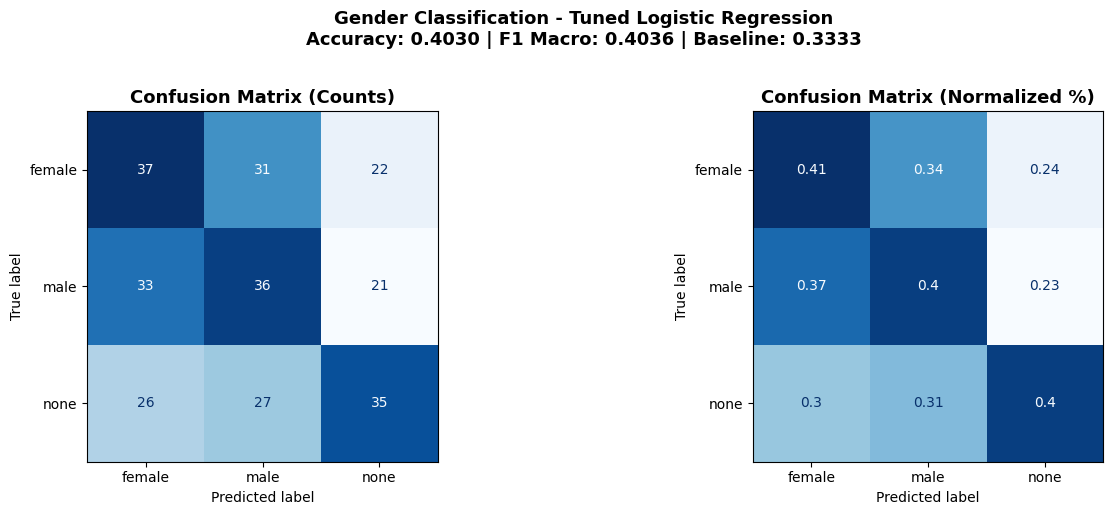

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = le.classes_
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalized
cm_norm = confusion_matrix(y_test, y_pred_lr, normalize='true')
ConfusionMatrixDisplay(confusion_matrix = cm_norm.round(2), display_labels = le.classes_
).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=13, fontweight='bold')

plt.suptitle('Gender Classification - Tuned Logistic Regression\n'
    'Accuracy: 0.4030 | F1 Macro: 0.4036 | Baseline: 0.3333',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../models/plots/clf_confusion_matrix_final.png', dpi=150)
plt.show()

### **COMPLETE JOURNEY VISUALIZATION**

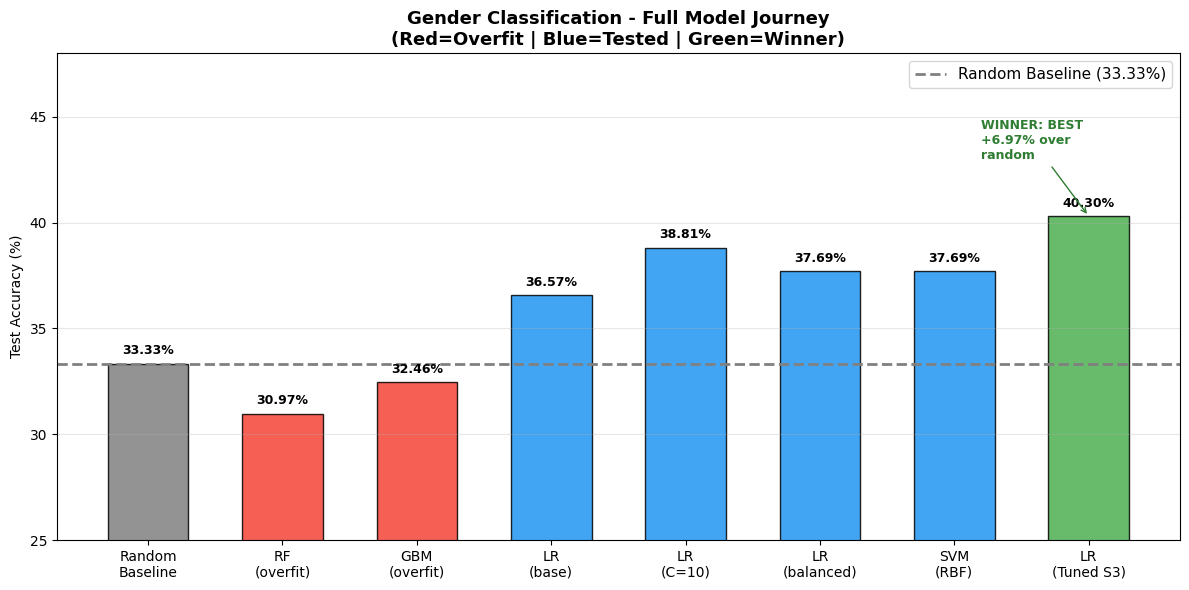

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

model_names = [
    'Random\nBaseline',
    'RF\n(overfit)',
    'GBM\n(overfit)',
    'LR\n(base)',
    'LR\n(C=10)',
    'LR\n(balanced)',
    'SVM\n(RBF)',
    'LR\n(Tuned S3)'   # WINNER
]
accuracies = [33.33, 30.97, 32.46, 36.57, 38.81, 37.69, 37.69, 40.30]
colors = [
    'gray',     # baseline
    '#F44336',  # overfit - red
    '#F44336',  # overfit - red
    '#2196F3',  # blue
    '#2196F3',  # blue
    '#2196F3',  # blue
    '#2196F3',  # blue
    '#4CAF50'   # winner - green
]

bars = ax.bar(
    model_names, accuracies, color = colors, edgecolor = 'black',
    alpha = 0.85, width = 0.6
)

# Baseline line
ax.axhline(y = 33.33, color = 'gray', linestyle = '--', linewidth = 2,
    label = 'Random Baseline (33.33%)'
)

# Value labels on bars
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
        f'{val:.2f}%',
        ha = 'center', va = 'bottom', fontweight = 'bold', fontsize = 9
    )

# Annotate winner
ax.annotate(
    'WINNER: BEST\n+6.97% over\nrandom',
    xy = (7, 40.30), xytext = (6.2, 43),
    fontsize = 9, fontweight = 'bold', color = '#2E7D32',
    arrowprops = dict(arrowstyle='->', color='#2E7D32')
)

ax.set_title(
    'Gender Classification - Full Model Journey\n'
    '(Red=Overfit | Blue=Tested | Green=Winner)',
    fontsize = 13, fontweight = 'bold'
)
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(25, 48)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../models/plots/clf_model_journey.png', dpi=150)
plt.show()

### **SAVE FINAL MODEL ARTIFACTS**

In [20]:
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# The tuned LR from Strategy 3 is our final model
artifacts = {
    'gender_classifier.pkl' : best_lr,
    'gender_label_encoder.pkl' : le,
    'clf_feature_columns.pkl' : X_train.columns.tolist(),
    'clf_scaler.pkl' : scaler_clf,
}

print("-> SAVING FINAL ARTIFACTS:")
for filename, obj in artifacts.items():
    path = os.path.join(MODELS_DIR, filename)
    joblib.dump(obj, path)
    print(f"   -> {filename}")

# VERIFY
loaded_clf = joblib.load(
    os.path.join(MODELS_DIR, 'gender_classifier.pkl'))
loaded_le = joblib.load(
    os.path.join(MODELS_DIR, 'gender_label_encoder.pkl'))
loaded_cols = joblib.load(
    os.path.join(MODELS_DIR, 'clf_feature_columns.pkl'))
loaded_scaler = joblib.load(
    os.path.join(MODELS_DIR, 'clf_scaler.pkl'))

# Test prediction
test_sample = X_test_scaled[:5]
preds_label = loaded_le.inverse_transform(
                   loaded_clf.predict(test_sample))
actual_label = loaded_le.inverse_transform(y_test[:5])

print(f"\n-> VERIFICATION - First 5 Predictions:")
print(f"   {'Predicted':10s} | {'Actual':10s} | Match")
print(f"   {'-'*34}")
for pred, actual in zip(preds_label, actual_label):
    match = "✓" if pred == actual else "✗"
    print(f"   {pred:10s} | {actual:10s} | {match}")

print(f"\n-> Feature columns saved : {len(loaded_cols)}")
print(f"-> Model type : {type(loaded_clf).__name__}")

-> SAVING FINAL ARTIFACTS:
   -> gender_classifier.pkl
   -> gender_label_encoder.pkl
   -> clf_feature_columns.pkl
   -> clf_scaler.pkl

-> VERIFICATION - First 5 Predictions:
   Predicted  | Actual     | Match
   ----------------------------------
   male       | male       | ✓
   none       | male       | ✗
   none       | male       | ✗
   male       | male       | ✓
   none       | none       | ✓

-> Feature columns saved : 27
-> Model type : LogisticRegression
